# Diagnóstico de Inadimplência — Investigação com Testes Estatísticos

Terceiro notebook da série (depois de `stats_tests_resumo_1`, `stats_tests_analista_dados` e `diagnostico_queda_receita`), no mesmo formato de investigação do notebook de queda de receita: uma base única simulada e 6 perguntas que vão te guiando até um perfil de risco acionável. Rode as células em ordem.

**O cenário:** a empresa vende a prazo (boleto/carnê) e uma parte das faturas atrasa. Temos 12 meses de faturas emitidas — os **9 meses anteriores** (`antes`, baseline) e os **3 meses mais recentes** (`depois`) — com informação de cliente, valor, histórico de relacionamento e se a fatura atrasou.

**As 6 perguntas deste notebook:**

| # | Pergunta | O que o código faz |
|---|---|---|
| 1 | Quais grupos de clientes têm maior inadimplência? | Qui-quadrado + proporções par a par entre segmentos, com correção |
| 2 | A inadimplência varia com o valor da compra? | Comparação de valor entre adimplentes/inadimplentes + tendência por faixa |
| 3 | Existe relação entre atraso e histórico de compras? | Inadimplência por faixa de histórico + correlação com dias de atraso |
| 4 | Quais regiões concentram mais inadimplentes? | Qui-quadrado + índice de concentração por região |
| 5 | A inadimplência subiu mais em clientes novos ou antigos? | Proporção por segmento, antes x depois, com correção |
| 6 | Quais características identificam risco de atraso? | Regressão logística combinando todos os fatores anteriores |

**Cuidado que atravessa o notebook inteiro:** inadimplência é um resultado **binário** por fatura (atrasou ou não) — a maioria das perguntas aqui é sobre se essa **proporção** difere entre grupos, o mesmo teste Z de proporções usado pra conversão/churn nos notebooks anteriores, só que "sucesso" agora é uma notícia ruim. A pergunta 6 foge dessa régua de propósito: quando você quer combinar **várias características ao mesmo tempo** (não uma de cada vez), o teste certo deixa de ser uma bateria de testes univariados e passa a ser um modelo — aqui, regressão logística.

## Base de dados da investigação

**O que o código faz:** simula uma tabela de faturas (uma linha por venda a prazo) como a que sairia de um sistema de contas a receber — segmento do cliente, região, valor da compra, histórico de compras anteriores, se é cliente novo ou antigo, e se a fatura atrasou (e por quantos dias, quando atrasou). Troque por `pd.read_sql(...)` / `pd.read_csv(...)` na sua base real — as próximas seções funcionam em cima de qualquer tabela com essas colunas.

Assim como no notebook de queda de receita, os parâmetros foram desenhados pra conter causas reais de inadimplência — é assim que verificamos se os testes das próximas seções conseguem *encontrar* o que sabemos que está lá.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(77)

# --- Calendário: 9 meses de baseline + 3 meses recentes ---
meses = ['Ago/25', 'Set/25', 'Out/25', 'Nov/25', 'Dez/25', 'Jan/26', 'Fev/26', 'Mar/26', 'Abr/26', 'Mai/26', 'Jun/26', 'Jul/26']
n_meses_antes, n_meses_depois = 9, 3
periodo_por_mes = {m: ('antes' if i < n_meses_antes else 'depois') for i, m in enumerate(meses)}

faturas_por_mes = {m: np.random.randint(950, 1050) for m in meses}
n_faturas = sum(faturas_por_mes.values())

mes_arr = np.repeat(meses, [faturas_por_mes[m] for m in meses])
periodo_arr = np.array([periodo_por_mes[m] for m in mes_arr])

# --- Dimensões da fatura/cliente ---
segmento_arr = np.random.choice(["Varejo", "Revenda", "Atacado"], size=n_faturas, p=[0.55, 0.30, 0.15])
regiao_arr = np.random.choice(
    ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"],
    size=n_faturas, p=[0.42, 0.20, 0.20, 0.10, 0.08]
)
tipo_arr = np.random.choice(["novo", "antigo"], size=n_faturas, p=[0.48, 0.52])

# --- Valor da compra (R$, distribuição assimétrica típica de fatura) ---
valor_arr = np.round(np.random.gamma(shape=2.5, scale=250, size=n_faturas), 2)
valor_arr = np.clip(valor_arr, 30, None)

# --- Histórico de compras: cliente novo tem poucas compras anteriores, antigo tem muitas ---
historico_arr = np.where(
    tipo_arr == "novo",
    np.random.poisson(2, size=n_faturas),
    np.random.poisson(14, size=n_faturas) + 2,
)

# --- Probabilidade de inadimplência: modelo logit combinando os fatores da investigação ---
BETA0 = -3.0
BETA_SEGMENTO = {"Varejo": 0.9, "Revenda": 0.0, "Atacado": -0.9}
BETA_REGIAO = {"Sudeste": 0.0, "Sul": -0.1, "Nordeste": 0.5, "Centro-Oeste": 0.0, "Norte": 0.6}
BETA_VALOR = -0.55       # aplicado a log(valor/500): compra maior -> menor risco
BETA_HIST = -0.06        # cada compra anterior reduz o risco
BETA_NOVO = 0.2          # cliente novo tem risco basal um pouco maior
BETA_DEPOIS = 0.3        # período recente tem risco basal um pouco maior (piora macro)
BETA_NOVO_X_DEPOIS = 0.6  # cliente novo é bem mais afetado pela piora recente

x_log_valor = np.log(valor_arr / 500)
logit = (
    BETA0
    + np.array([BETA_SEGMENTO[s] for s in segmento_arr])
    + np.array([BETA_REGIAO[r] for r in regiao_arr])
    + BETA_VALOR * x_log_valor
    + BETA_HIST * historico_arr
    + BETA_NOVO * (tipo_arr == "novo")
    + BETA_DEPOIS * (periodo_arr == "depois")
    + BETA_NOVO_X_DEPOIS * ((tipo_arr == "novo") & (periodo_arr == "depois"))
)
prob_inadimplencia = 1 / (1 + np.exp(-logit))
inadimplente_arr = (np.random.rand(n_faturas) < prob_inadimplencia).astype(int)

# --- Dias de atraso: só pra quem atrasou; cliente com mais histórico atrasa por menos tempo ---
dias_atraso_arr = np.zeros(n_faturas)
idx_inad = np.where(inadimplente_arr == 1)[0]
escala_atraso = np.clip(60 - 1.5 * historico_arr[idx_inad], 8, None)
dias_atraso_arr[idx_inad] = np.round(10 + np.random.gamma(shape=2, scale=escala_atraso / 2), 0)

faturas = pd.DataFrame({
    "fatura_id": np.arange(n_faturas),
    "mes": pd.Categorical(mes_arr, categories=meses, ordered=True),
    "periodo": periodo_arr,
    "segmento_cliente": segmento_arr,
    "regiao": regiao_arr,
    "cliente_tipo": tipo_arr,
    "valor_compra": valor_arr,
    "historico_compras": historico_arr,
    "inadimplente": inadimplente_arr,
    "dias_atraso": dias_atraso_arr,
})

faixas_valor = [0, 300, 700, 1500, np.inf]
labels_valor = ["Até R$300", "R$300-700", "R$700-1.500", "Acima de R$1.500"]
faturas["faixa_valor"] = pd.cut(faturas["valor_compra"], bins=faixas_valor, labels=labels_valor)

faixas_hist = [-1, 2, 10, np.inf]
labels_hist = ["Baixo (0-2 compras)", "Médio (3-10 compras)", "Alto (11+ compras)"]
faturas["faixa_historico"] = pd.cut(faturas["historico_compras"], bins=faixas_hist, labels=labels_hist)

print(f"Faturas: {len(faturas):,}".replace(",", "."))
print(f"Taxa de inadimplência geral: {faturas['inadimplente'].mean():.2%}")
print(faturas.head(3))

Faturas: 12.097
Taxa de inadimplência geral: 8.72%
   fatura_id     mes periodo segmento_cliente   regiao cliente_tipo  \
0          0  Ago/25   antes           Varejo  Sudeste         novo   
1          1  Ago/25   antes           Varejo  Sudeste       antigo   
2          2  Ago/25   antes           Varejo    Norte       antigo   

   valor_compra  historico_compras  inadimplente  dias_atraso  \
0        384.58                  3             0          0.0   
1        625.65                 21             1         42.0   
2       1604.75                 17             0          0.0   

        faixa_valor       faixa_historico  
0         R$300-700  Médio (3-10 compras)  
1         R$300-700    Alto (11+ compras)  
2  Acima de R$1.500    Alto (11+ compras)  


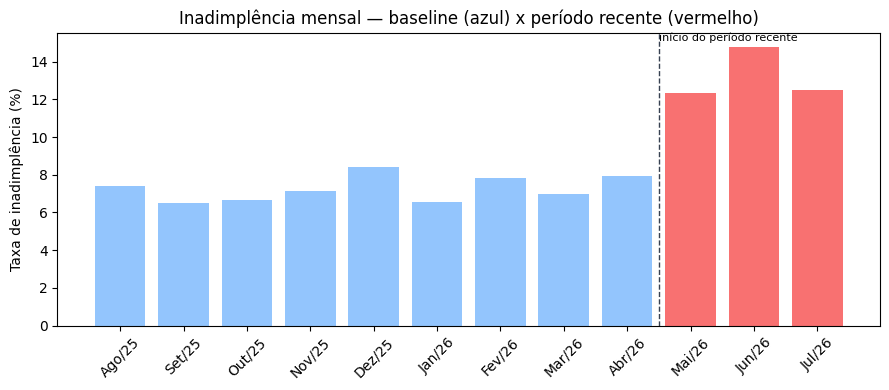

In [2]:
import matplotlib.pyplot as plt

inad_mensal = faturas.groupby("mes", observed=True)["inadimplente"].mean().reindex(meses)

fig, ax = plt.subplots(figsize=(9, 4))
cores = ["#93c5fd" if periodo_por_mes[m] == "antes" else "#f87171" for m in meses]
ax.bar(meses, inad_mensal.values * 100, color=cores)
ax.axvline(n_meses_antes - 0.5, color="#374151", linestyle="--", linewidth=1)
ax.text(n_meses_antes - 0.5, inad_mensal.max() * 100 * 1.02, "início do período recente", fontsize=8, ha="left")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_title("Inadimplência mensal — baseline (azul) x período recente (vermelho)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A inadimplência tem uma taxa de base ao longo do ano e sobe visivelmente no período recente. As próximas 6 seções quebram esse número em grupos até achar onde o risco está concentrado.

## 1. Quais grupos de clientes apresentam maior inadimplência?

**Contexto:** a carteira tem três segmentos de cliente — Varejo, Revenda e Atacado — que compram em condições diferentes. A pergunta é se a inadimplência é parecida entre eles ou se algum segmento concentra o risco.

**O que o código faz:** roda um qui-quadrado geral (segmento x inadimplência) pra testar se existe associação, e depois um teste Z de proporções **par a par** entre os três segmentos (Varejo x Revenda, Varejo x Atacado, Revenda x Atacado) — mesma lógica de post-hoc do Tukey HSD do `stats_tests_resumo_1`, adaptada pra proporções — com correção de FDR pra não superestimar quantos pares realmente diferem.

In [3]:
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from itertools import combinations

resumo_segmento = faturas.groupby("segmento_cliente")["inadimplente"].agg(["count", "sum", "mean"]).rename(
    columns={"count": "faturas", "sum": "inadimplentes", "mean": "taxa_inadimplencia"}
)
print(resumo_segmento.round(4))

tabela = pd.crosstab(faturas["segmento_cliente"], faturas["inadimplente"])
chi2, p_geral, dof, esperado = chi2_contingency(tabela)
print(f"\nQui-quadrado geral (segmento x inadimplência): p-value = {p_geral:.2e}")

# --- Comparações par a par entre segmentos ---
segmentos = resumo_segmento.index.tolist()
pares, p_values = [], []
for s1, s2 in combinations(segmentos, 2):
    suc = [resumo_segmento.loc[s1, "inadimplentes"], resumo_segmento.loc[s2, "inadimplentes"]]
    obs = [resumo_segmento.loc[s1, "faturas"], resumo_segmento.loc[s2, "faturas"]]
    z, p = proportions_ztest(suc, obs)
    pares.append(f"{s1} x {s2}")
    p_values.append(p)

rejeita_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
comparacoes = pd.DataFrame({"comparacao": pares, "p_value_bruto": p_values, "p_value_fdr": p_fdr, "diferenca_significativa": rejeita_fdr})
print("\nComparações par a par:")
print(comparacoes.round(4))

                  faturas  inadimplentes  taxa_inadimplencia
segmento_cliente                                            
Atacado              1782             41              0.0230
Revenda              3588            213              0.0594
Varejo               6727            801              0.1191

Qui-quadrado geral (segmento x inadimplência): p-value = 5.57e-47

Comparações par a par:
          comparacao  p_value_bruto  p_value_fdr  diferenca_significativa
0  Atacado x Revenda            0.0          0.0                     True
1   Atacado x Varejo            0.0          0.0                     True
2   Revenda x Varejo            0.0          0.0                     True


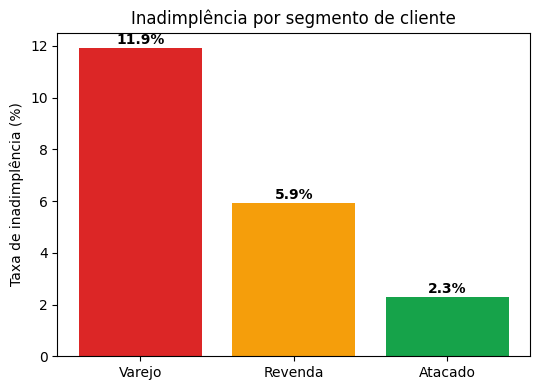

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4))
ordem = resumo_segmento.sort_values("taxa_inadimplencia", ascending=False).index
taxas = resumo_segmento.loc[ordem, "taxa_inadimplencia"] * 100
ax.bar(ordem, taxas, color=["#dc2626", "#f59e0b", "#16a34a"])
for i, v in enumerate(taxas):
    ax.text(i, v + 0.15, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_title("Inadimplência por segmento de cliente")
plt.tight_layout()
plt.show()

**Leitura do resultado:** o qui-quadrado geral confirma que segmento e inadimplência estão associados — não é coincidência de amostra. As comparações par a par mostram que os três segmentos diferem entre si mesmo depois da correção — não é só Varejo e Atacado nos extremos, Revenda também se distingue dos outros dois, formando uma escada clara de risco (Atacado < Revenda < Varejo). Vale lembrar, como nas outras seções: com uma base grande, "significativo" garante que a diferença é real, não garante que ela é grande — a tabela de taxas é que mostra o tamanho de cada degrau.

**Decisão de negócio:** o segmento com maior taxa concentra o risco novo (política de crédito, garantias exigidas, prazo de pagamento) — vale revisar critérios de aprovação especificamente pra esse segmento em vez de endurecer a política pra carteira inteira, o que penalizaria também os segmentos que já pagam bem.

## 2. A inadimplência varia de acordo com o valor da compra?

**Contexto:** intuições sobre valor e risco podem ir nos dois sentidos — compra grande pode significar cliente mais capitalizado (menor risco) ou maior exposição em caso de atraso (mais impacto se der errado). O teste separa "o valor está associado ao risco" de "o valor tem mais impacto financeiro quando o risco se realiza" — aqui olhamos a primeira pergunta.

**O que o código faz:** compara o valor médio da compra entre faturas adimplentes e inadimplentes (t de Welch, amostra grande o suficiente pra CLT mesmo com a assimetria do valor) e testa a tendência ao longo de faixas de valor com qui-quadrado.

In [5]:
from scipy.stats import ttest_ind, mannwhitneyu

valor_adimplente = faturas.loc[faturas["inadimplente"] == 0, "valor_compra"]
valor_inadimplente = faturas.loc[faturas["inadimplente"] == 1, "valor_compra"]

print(f"Valor médio (adimplente):   R$ {valor_adimplente.mean():.2f}")
print(f"Valor médio (inadimplente): R$ {valor_inadimplente.mean():.2f}")

t_stat, p_welch = ttest_ind(valor_inadimplente, valor_adimplente, equal_var=False)
u_stat, p_mw = mannwhitneyu(valor_inadimplente, valor_adimplente)
print(f"\np-value (Welch, compara médias):     {p_welch:.2e}")
print(f"p-value (Mann-Whitney, robustez):    {p_mw:.2e}")

# --- Tendência por faixa de valor ---
resumo_faixa = faturas.groupby("faixa_valor", observed=True)["inadimplente"].agg(["count", "mean"]).rename(
    columns={"count": "faturas", "mean": "taxa_inadimplencia"}
)
print("\nInadimplência por faixa de valor:")
print(resumo_faixa.round(4))

import pandas as pd
from scipy.stats import chi2_contingency
tabela_faixa = pd.crosstab(faturas["faixa_valor"], faturas["inadimplente"])
chi2, p_faixa, dof, esperado = chi2_contingency(tabela_faixa)
print(f"\nQui-quadrado (faixa de valor x inadimplência): p-value = {p_faixa:.2e}")

Valor médio (adimplente):   R$ 633.86
Valor médio (inadimplente): R$ 517.52

p-value (Welch, compara médias):     2.28e-21
p-value (Mann-Whitney, robustez):    2.10e-25

Inadimplência por faixa de valor:
                  faturas  taxa_inadimplencia
faixa_valor                                  
Até R$300            2532              0.1363
R$300-700            5416              0.0812
R$700-1.500          3706              0.0672
Acima de R$1.500      443              0.0474

Qui-quadrado (faixa de valor x inadimplência): p-value = 6.48e-23


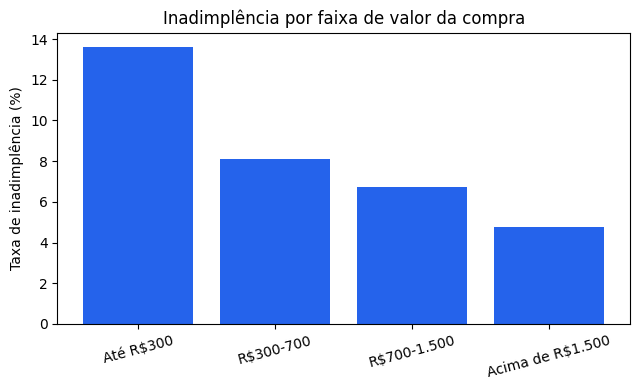

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(resumo_faixa.index.astype(str), resumo_faixa["taxa_inadimplencia"] * 100, color="#2563eb")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_title("Inadimplência por faixa de valor da compra")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Leitura do resultado:** o valor médio das faturas inadimplentes é menor que o das adimplentes, e os dois testes (Welch e Mann-Whitney) concordam — não é só um efeito de outlier puxando a média. A tabela por faixa mostra o padrão de forma mais direta pro negócio: a inadimplência **cai conforme o valor da compra sobe**, de forma praticamente monotônica.

**Decisão de negócio:** isso é consistente com compras pequenas passando por aprovação de crédito mais automática/frouxa, enquanto compras grandes costumam ter uma análise mais criteriosa. Não signfica que compra grande é livre de risco (o valor em jogo é maior quando dá errado) — mas sim que, em **taxa**, o risco por fatura está concentrado nas compras de ticket baixo. Vale considerar regra de aprovação mais rigorosa especificamente pra faixa de valor baixo.

## 3. Existe relação entre atraso e histórico de compras?

**Contexto:** "histórico de compras" aqui é o número de compras que o cliente já fez antes dessa fatura — um proxy de relacionamento/confiança. A pergunta tem duas camadas: (a) cliente com mais histórico atrasa **menos vezes**? e (b) quando atrasa, atrasa por **menos tempo**?

**O que o código faz:** pra (a), agrupa o histórico em faixas (baixo/médio/alto) e testa com qui-quadrado se a taxa de inadimplência muda entre elas. Pra (b), calcula a correlação de Spearman (não assume relação linear, e é robusta a outliers de dias de atraso) entre histórico de compras e dias de atraso, olhando só as faturas que de fato atrasaram.

In [7]:
import pandas as pd
from scipy.stats import chi2_contingency, spearmanr

# --- (a) Taxa de inadimplência por faixa de histórico ---
resumo_hist = faturas.groupby("faixa_historico", observed=True)["inadimplente"].agg(["count", "mean"]).rename(
    columns={"count": "faturas", "mean": "taxa_inadimplencia"}
)
print("Inadimplência por faixa de histórico de compras:")
print(resumo_hist.round(4))

tabela_hist = pd.crosstab(faturas["faixa_historico"], faturas["inadimplente"])
chi2, p_hist, dof, esperado = chi2_contingency(tabela_hist)
print(f"\nQui-quadrado (faixa de histórico x inadimplência): p-value = {p_hist:.2e}")

# --- (b) Correlação entre histórico e dias de atraso, só entre quem atrasou ---
atrasados = faturas[faturas["inadimplente"] == 1]
rho, p_rho = spearmanr(atrasados["historico_compras"], atrasados["dias_atraso"])
print(f"\nCorrelação de Spearman (histórico x dias de atraso, só inadimplentes): rho = {rho:.3f}, p-value = {p_rho:.2e}")
print(f"Dias de atraso médios: {atrasados['dias_atraso'].mean():.1f} dias")

Inadimplência por faixa de histórico de compras:
                      faturas  taxa_inadimplencia
faixa_historico                                  
Baixo (0-2 compras)      3905              0.1334
Médio (3-10 compras)     2309              0.1122
Alto (11+ compras)       5883              0.0467

Qui-quadrado (faixa de histórico x inadimplência): p-value = 1.13e-53

Correlação de Spearman (histórico x dias de atraso, só inadimplentes): rho = -0.187, p-value = 9.65e-10
Dias de atraso médios: 60.4 dias


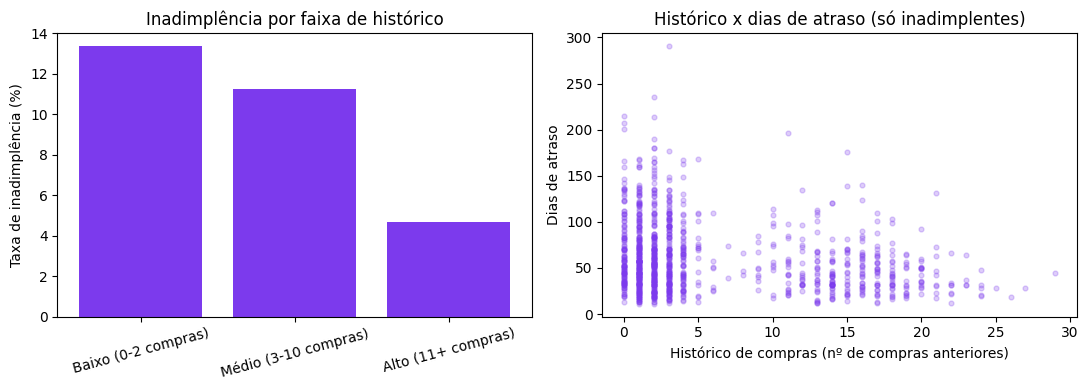

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(resumo_hist.index.astype(str), resumo_hist["taxa_inadimplencia"] * 100, color="#7c3aed")
axes[0].set_ylabel("Taxa de inadimplência (%)")
axes[0].set_title("Inadimplência por faixa de histórico")
axes[0].tick_params(axis="x", rotation=15)

axes[1].scatter(atrasados["historico_compras"], atrasados["dias_atraso"], alpha=0.25, color="#7c3aed", s=12)
axes[1].set_xlabel("Histórico de compras (nº de compras anteriores)")
axes[1].set_ylabel("Dias de atraso")
axes[1].set_title("Histórico x dias de atraso (só inadimplentes)")

plt.tight_layout()
plt.show()

**Leitura do resultado:** o qui-quadrado confirma que a chance de atrasar cai conforme o histórico de compras aumenta — cliente com relacionamento mais longo tende a ser mais confiável. A correlação de Spearman negativa (e significativa) mostra a segunda camada: entre quem atrasa, quem tem mais histórico também atrasa por **menos dias** — não é só "atrasa menos vezes", é "quando atrasa, o atraso é mais curto".

**Decisão de negócio:** histórico de compras é um sinal de risco forte e barato de obter (já está no seu próprio sistema, não depende de bureau externo) — vale usar como critério de flexibilização de prazo/limite pra clientes antigos, e como sinal de atenção redobrada logo nas primeiras compras de um cliente novo, período em que esse histórico protetor ainda não existe.

## 4. Quais regiões apresentam maior concentração de inadimplentes?

**Contexto:** além da taxa de inadimplência por região, "concentração" também é sobre **participação**: uma região pode ter poucos clientes mas responder por uma fatia desproporcional dos inadimplentes da carteira — isso é diferente de simplesmente ter a taxa mais alta.

**O que o código faz:** calcula a taxa de inadimplência por região (qui-quadrado + proporções par a par região x resto, com correção) e, adicionalmente, um **índice de concentração** = (% dos inadimplentes que vêm da região) / (% da carteira que a região representa). Índice acima de 1 significa que a região está sobrerrepresentada entre os inadimplentes frente ao seu tamanho na carteira.

In [9]:
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

resumo_regiao = faturas.groupby("regiao")["inadimplente"].agg(["count", "sum", "mean"]).rename(
    columns={"count": "faturas", "sum": "inadimplentes", "mean": "taxa_inadimplencia"}
)

tabela_regiao = pd.crosstab(faturas["regiao"], faturas["inadimplente"])
chi2, p_geral, dof, esperado = chi2_contingency(tabela_regiao)
print(f"Qui-quadrado geral (região x inadimplência): p-value = {p_geral:.2e}")

# --- Cada região x o resto da carteira, com correção ---
regioes = resumo_regiao.index.tolist()
p_values = []
for r in regioes:
    suc = [resumo_regiao.loc[r, "inadimplentes"], resumo_regiao["inadimplentes"].sum() - resumo_regiao.loc[r, "inadimplentes"]]
    obs = [resumo_regiao.loc[r, "faturas"], resumo_regiao["faturas"].sum() - resumo_regiao.loc[r, "faturas"]]
    z, p = proportions_ztest(suc, obs)
    p_values.append(p)

rejeita_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
resumo_regiao["p_value_fdr"] = p_fdr
resumo_regiao["diferenca_significativa"] = rejeita_fdr  # bicaudal: pode ser p/ mais OU p/ menos, ver índice abaixo

# --- Índice de concentração ---
resumo_regiao["pct_carteira"] = resumo_regiao["faturas"] / resumo_regiao["faturas"].sum()
resumo_regiao["pct_inadimplentes"] = resumo_regiao["inadimplentes"] / resumo_regiao["inadimplentes"].sum()
resumo_regiao["indice_concentracao"] = resumo_regiao["pct_inadimplentes"] / resumo_regiao["pct_carteira"]

print("\nInadimplência e concentração por região:")
print(resumo_regiao[["faturas", "taxa_inadimplencia", "pct_carteira", "pct_inadimplentes", "indice_concentracao", "p_value_fdr", "diferenca_significativa"]]
      .sort_values("indice_concentracao", ascending=False).round(4))

Qui-quadrado geral (região x inadimplência): p-value = 6.35e-13

Inadimplência e concentração por região:
              faturas  taxa_inadimplencia  pct_carteira  pct_inadimplentes  \
regiao                                                                       
Norte             961              0.1363        0.0794             0.1242   
Nordeste         2435              0.1113        0.2013             0.2569   
Sul              2385              0.0763        0.1972             0.1725   
Centro-Oeste     1206              0.0763        0.0997             0.0872   
Sudeste          5110              0.0742        0.4224             0.3592   

              indice_concentracao  p_value_fdr  diferenca_significativa  
regiao                                                                   
Norte                      1.5631       0.0000                     True  
Nordeste                   1.2761       0.0000                     True  
Sul                        0.8750       0.0440     

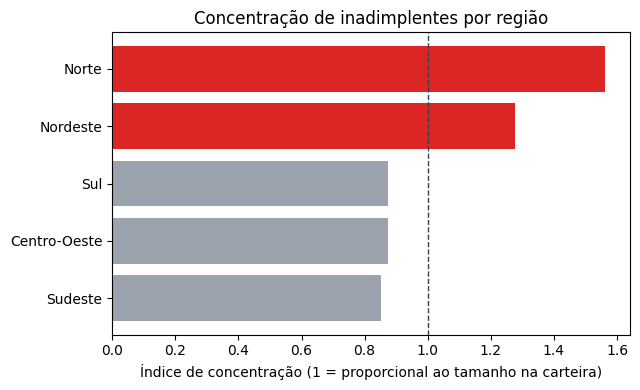

In [10]:
import matplotlib.pyplot as plt

ordem = resumo_regiao.sort_values("indice_concentracao", ascending=True).index
fig, ax = plt.subplots(figsize=(6.5, 4))
cores = ["#dc2626" if v > 1 else "#9ca3af" for v in resumo_regiao.loc[ordem, "indice_concentracao"]]
ax.barh(ordem, resumo_regiao.loc[ordem, "indice_concentracao"], color=cores)
ax.axvline(1, color="#374151", linewidth=1, linestyle="--")
ax.set_xlabel("Índice de concentração (1 = proporcional ao tamanho na carteira)")
ax.set_title("Concentração de inadimplentes por região")
plt.tight_layout()
plt.show()

**Leitura do resultado:** o qui-quadrado confirma associação entre região e inadimplência. Repare que o teste par a par é **bicaudal** — "diferença significativa" não diz se é pra mais ou pra menos, só o índice de concentração (acima ou abaixo de 1) mostra a direção. Com uma base grande, é comum várias regiões darem significativas ao mesmo tempo: normalmente duas regiões aparecem com índice **acima** de 1 (sobrerrepresentadas — concentram mais inadimplentes do que o tamanho delas na carteira sugere) e outras com índice **abaixo** de 1 (sub-representadas, ou seja, mais confiáveis que a média, não mais arriscadas) — mesmo as duas leituras sendo estatisticamente "reais". Uma região pequena com índice bem acima de 1 pesa mais na conversa de risco do que o tamanho dela na carteira sugere à primeira vista, mesmo que uma região maior tenha mais inadimplentes em número absoluto.

**Decisão de negócio:** priorize as regiões com índice de concentração acima de 1 (não necessariamente a de maior taxa bruta, nem toda região que deu "significativa" no teste) pra ações de cobrança/crédito direcionadas — vale investigar causas locais (renda regional, sazonalidade, logística de cobrança) antes de aplicar uma política nacional uniforme.

## 5. A inadimplência aumentou mais entre clientes novos ou antigos?

**Contexto:** a visão geral (primeiro gráfico do notebook) já mostrou que a inadimplência subiu no período recente — a pergunta agora é se essa piora é igual pros dois perfis de cliente ou se está concentrada em um deles. Mesma lógica da seção "canais" e "novos x recorrentes" do notebook de queda de receita: teste `antes x depois` **separado por segmento**, com correção de múltiplos testes.

**O que o código faz:** calcula a inadimplência de clientes novos e antigos em cada período, testa a diferença `antes x depois` pra cada grupo, e aplica correção FDR nos dois testes.

In [11]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

tipos = ["novo", "antigo"]
linhas, p_values = [], []
for t in tipos:
    sub = faturas[faturas["cliente_tipo"] == t]
    antes = sub[sub["periodo"] == "antes"]
    depois = sub[sub["periodo"] == "depois"]
    taxa_a, taxa_d = antes["inadimplente"].mean(), depois["inadimplente"].mean()
    z, p = proportions_ztest(
        [antes["inadimplente"].sum(), depois["inadimplente"].sum()],
        [len(antes), len(depois)]
    )
    linhas.append({"cliente_tipo": t, "taxa_antes": taxa_a, "taxa_depois": taxa_d,
                    "variacao_relativa": (taxa_d - taxa_a) / taxa_a, "variacao_pp": (taxa_d - taxa_a) * 100})
    p_values.append(p)

resultado_tipo = pd.DataFrame(linhas).set_index("cliente_tipo")
rejeita_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
resultado_tipo["p_value_fdr"] = p_fdr
resultado_tipo["piora_significativa"] = rejeita_fdr

print(resultado_tipo.round(4))

              taxa_antes  taxa_depois  variacao_relativa  variacao_pp  \
cliente_tipo                                                            
novo              0.1035       0.2113             1.0424      10.7868   
antigo            0.0442       0.0597             0.3489       1.5434   

              p_value_fdr  piora_significativa  
cliente_tipo                                    
novo               0.0000                 True  
antigo             0.0138                 True  


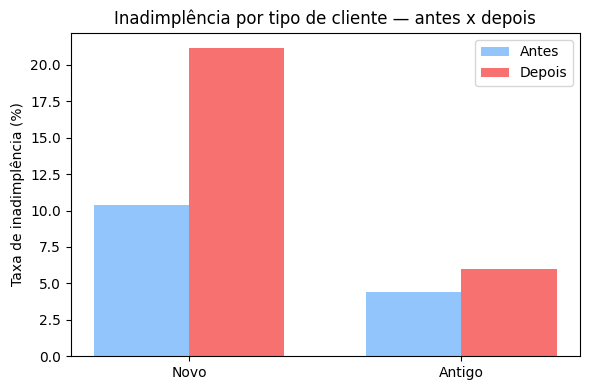

In [12]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(tipos))
largura = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - largura/2, resultado_tipo["taxa_antes"] * 100, largura, label="Antes", color="#93c5fd")
ax.bar(x + largura/2, resultado_tipo["taxa_depois"] * 100, largura, label="Depois", color="#f87171")
ax.set_xticks(x)
ax.set_xticklabels(["Novo", "Antigo"])
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_title("Inadimplência por tipo de cliente — antes x depois")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura do resultado:** os dois grupos podem aparecer como "significativos" depois da correção (base grande de novo detecta até pioras pequenas) — o que separa a história real é o **tamanho** da piora: clientes novos costumam dobrar (ou mais) a taxa de inadimplência, um salto de vários pontos percentuais; clientes antigos também pioram, mas o salto em pontos percentuais costuma ser bem menor, mesmo a variação relativa deles não sendo desprezível. Isso é coerente com a seção 3: cliente antigo tem o "colchão" do histórico de relacionamento, que amortece a piora do cenário; cliente novo não tem esse colchão ainda.

**Decisão de negócio:** se a piora recente está concentrada em clientes novos, o ajuste de política de crédito (limite inicial, exigência de garantia, prazo mais curto na primeira compra) deve mirar especificamente a **entrada** de novos clientes na carteira recente — apertar a política pra toda a base penalizaria clientes antigos que não são a origem da piora.

## 6. Quais características permitem identificar clientes com maior risco de atraso?

**Por que muda de ferramenta aqui:** as seções 1 a 5 testaram cada característica **isoladamente** — mas segmento, região, valor e histórico estão todos correlacionados entre si na prática (ex: cliente novo tende a ter histórico baixo por definição). Rodar testes separados não diz quanto cada característica pesa **depois de descontar as outras**. Pra isso, o teste certo deixa de ser uma bateria de testes univariados e passa a ser um **modelo multivariado** — aqui, uma regressão logística, que estima o efeito de cada característica já controlando pelas demais.

**Como ler:** cada coeficiente vira um **odds ratio** (`exp(coeficiente)`) — acima de 1 aumenta a chance de atraso, abaixo de 1 reduz, e o tamanho do desvio em relação a 1 é o tamanho do efeito. O p-value de cada linha testa se aquele efeito é distinguível de zero **depois de controlar por todo o resto**.

In [13]:
import statsmodels.formula.api as smf
import numpy as np

modelo = smf.logit(
    "inadimplente ~ C(segmento_cliente, Treatment('Revenda')) "
    "+ C(regiao, Treatment('Sudeste')) "
    "+ np.log(valor_compra) "
    "+ historico_compras "
    "+ C(cliente_tipo, Treatment('antigo')) "
    "+ C(periodo, Treatment('antes')) "
    "+ C(cliente_tipo, Treatment('antigo')):C(periodo, Treatment('antes'))",
    data=faturas
).fit(disp=0)

resumo_modelo = pd.DataFrame({
    "coeficiente": modelo.params,
    "odds_ratio": np.exp(modelo.params),
    "p_value": modelo.pvalues,
}).round(4)
resumo_modelo = resumo_modelo.sort_values("p_value")
print(resumo_modelo)
print(f"\nPseudo R² (McFadden): {modelo.prsquared:.3f}")

                                                    coeficiente  odds_ratio  \
C(segmento_cliente, Treatment('Revenda'))[T.Ata...      -0.9906      0.3714   
C(segmento_cliente, Treatment('Revenda'))[T.Var...       0.8644      2.3735   
C(regiao, Treatment('Sudeste'))[T.Norte]                 0.7839      2.1901   
C(regiao, Treatment('Sudeste'))[T.Nordeste]              0.5402      1.7163   
np.log(valor_compra)                                    -0.5659      0.5678   
C(cliente_tipo, Treatment('antigo'))[T.novo]:C(...       0.5801      1.7863   
historico_compras                                       -0.0479      0.9533   
C(periodo, Treatment('antes'))[T.depois]                 0.3374      1.4014   
C(cliente_tipo, Treatment('antigo'))[T.novo]             0.3286      1.3890   
Intercept                                                0.4018      1.4945   
C(regiao, Treatment('Sudeste'))[T.Sul]                  -0.0211      0.9791   
C(regiao, Treatment('Sudeste'))[T.Centro-Oeste]     

In [14]:
import pandas as pd

# --- Exemplo prático: probabilidade prevista pra alguns perfis de cliente ---
perfis = pd.DataFrame([
    {"segmento_cliente": "Varejo", "regiao": "Norte", "valor_compra": 200, "historico_compras": 1, "cliente_tipo": "novo", "periodo": "depois"},
    {"segmento_cliente": "Atacado", "regiao": "Sudeste", "valor_compra": 2000, "historico_compras": 20, "cliente_tipo": "antigo", "periodo": "depois"},
    {"segmento_cliente": "Varejo", "regiao": "Sudeste", "valor_compra": 500, "historico_compras": 5, "cliente_tipo": "novo", "periodo": "depois"},
    {"segmento_cliente": "Revenda", "regiao": "Sul", "valor_compra": 800, "historico_compras": 10, "cliente_tipo": "antigo", "periodo": "antes"},
])
perfis["probabilidade_prevista_atraso"] = modelo.predict(perfis)
print(perfis[["segmento_cliente", "regiao", "valor_compra", "historico_compras", "cliente_tipo", "periodo", "probabilidade_prevista_atraso"]]
      .sort_values("probabilidade_prevista_atraso", ascending=False).round(3))

  segmento_cliente   regiao  valor_compra  historico_compras cliente_tipo  \
0           Varejo    Norte           200                  1         novo   
2           Varejo  Sudeste           500                  5         novo   
3          Revenda      Sul           800                 10       antigo   
1          Atacado  Sudeste          2000                 20       antigo   

  periodo  probabilidade_prevista_atraso  
0  depois                          0.562  
2  depois                          0.224  
3   antes                          0.020  
1  depois                          0.004  


**Leitura do resultado:** os sinais dos coeficientes devem bater com o que as seções 1 a 5 já mostraram isoladamente — segmento Varejo e regiões como Norte/Nordeste com odds ratio acima de 1 (mais risco), valor da compra e histórico de compras com odds ratio abaixo de 1 (protegem). O fato de os sinais confirmarem os achados anteriores é o teste de sanidade do modelo — se um sinal aparecesse invertido aqui, seria motivo pra investigar colinearidade antes de confiar no resultado.

**Um detalhe que só o modelo multivariado revela:** repare que o efeito principal de "cliente novo" sozinho pode não ser significativo (p bem acima de 0,05), enquanto o termo de **interação** "cliente novo x período depois" é claramente significativo. Ou seja: ser cliente novo, por si só, não carregava risco extra controlando pelas outras variáveis no período `antes` — o risco elevado aparece especificamente na combinação "novo + período recente", exatamente o achado da seção 5, só que agora isolado do efeito de baixo histórico/ticket baixo que normalmente anda junto com "ser novo". É esse tipo de nuance que um teste univariado sozinho não separa.

A tabela de perfis exemplifica o uso prático: o mesmo modelo que serviu pra **explicar** o risco também serve pra **prever** a probabilidade de atraso de uma fatura nova, dado o perfil do cliente — a base de um score de crédito simples.

**Decisão de negócio:** o perfil de maior risco combina as características que mais pesaram nas seções anteriores ao mesmo tempo (cliente novo, ticket baixo, segmento e região de risco, no período recente) — é nesse cruzamento que a política de crédito deve ser mais rígida. Como o pseudo R² de um modelo logístico raramente chega perto de 1 (diferente do R² de regressão linear), não espere um número alto — o valor dele está mais em **ordenar** clientes por risco do que em explicar 100% da variação.

## Síntese — perfil de risco encontrado

| Pergunta | Achado | Teste usado | Ação recomendada |
|---|---|---|---|
| Grupos de clientes | Segmentos nos extremos (ex: Varejo x Atacado) diferem de forma clara; segmento intermediário nem sempre se distingue dos dois | Qui-quadrado + proporções par a par com correção | Revisar critério de aprovação por segmento, não pra carteira inteira |
| Valor da compra | Inadimplência cai conforme o valor sobe — compras de ticket baixo concentram o risco | Welch + Mann-Whitney + qui-quadrado por faixa | Aprovação mais criteriosa para compras de ticket baixo |
| Histórico de compras | Mais histórico reduz tanto a chance de atrasar quanto a duração do atraso | Qui-quadrado por faixa + correlação de Spearman | Usar histórico como sinal de risco nativo, redobrar atenção nas primeiras compras |
| Regiões | Concentração desproporcional numa região pequena, além da taxa mais alta | Qui-quadrado + proporções com correção + índice de concentração | Priorizar a região de maior índice de concentração, não só a de maior taxa bruta |
| Novos x antigos | Piora recente concentrada em clientes novos | Teste Z por segmento antes x depois, com correção | Apertar política de crédito na entrada de clientes novos, não na base toda |
| Características combinadas | Modelo confirma os achados anteriores atuando juntos, com o cruzamento novo + ticket baixo + região de risco como pior perfil | Regressão logística (odds ratio) | Usar o modelo como score de aprovação/priorização de cobrança |

**Como ler a tabela junto:** as seções 1 a 5 respondem "essa característica importa, isoladamente?" — a seção 6 responde "quais dessas características ainda importam quando todas competem ao mesmo tempo?". As duas visões se completam: os testes univariados são mais fáceis de explicar pra quem não trabalha com modelo (uma tabela, um p-value), e o modelo é o que efetivamente vira um score utilizável fatura a fatura.